# Import Libraries

In [1]:
import gc
gc.collect()

51

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import math
from pathlib import Path
import warnings
# Suppress Python warnings (Scikit-Learn, Pandas, etc.)
warnings.filterwarnings("ignore")

# Load Dataset

In [3]:
# Project root is one level up from the Notebook folder
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "Notebook" else Path.cwd()
DATA_DIR   = PROJECT_ROOT / "Data"
MODEL_DIR  = PROJECT_ROOT / "Model"          # ← fixed

df = pd.read_csv(DATA_DIR / "Melbourne_housing.csv")

In [4]:
main_df = df.copy()
df1 = df.copy()
df2 = df.copy()
df3 = df.copy()

In [5]:
df1 = df1.dropna()
df1.isnull().sum()

Suburb           0
Address          0
Rooms            0
Type             0
Method           0
SellerG          0
Date             0
Distance         0
Postcode         0
Bedroom          0
Bathroom         0
Car              0
Landsize         0
BuildingArea     0
YearBuilt        0
CouncilArea      0
Latitude         0
Longitude        0
Regionname       0
Propertycount    0
ParkingArea      0
Price            0
dtype: int64

# Dataset Overview

In [6]:
df.head()

,Suburb,Address,Rooms,Type,Method,SellerG,Date,Distance,Postcode,Bedroom,...,Landsize,BuildingArea,YearBuilt,CouncilArea,Latitude,Longitude,Regionname,Propertycount,ParkingArea,Price
0,Abbotsford,68 Studley St,2,h,SS,Jellis,3/9/2016,2.5,3067.0,2.0,...,126.0,inf,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0,Carport,NaN
1,Airport West,154 Halsey Rd,3,t,PI,Nelson,3/9/2016,13.5,3042.0,3.0,...,303.0,225,2016.0,Moonee Valley City Council,-37.7180,144.8780,Western Metropolitan,3464.0,Detached Garage,840000.0
2,Albert Park,105 Kerferd Rd,2,h,S,hockingstuart,3/9/2016,3.3,3206.0,2.0,...,120.0,82,1900.0,Port Phillip City Council,-37.8459,144.9555,Southern Metropolitan,3280.0,Attached Garage,1275000.0
3,Albert Park,85 Richardson St,2,h,S,Thomson,3/9/2016,3.3,3206.0,2.0,...,159.0,inf,NaN,Port Phillip City Council,-37.8450,144.9538,Southern Metropolitan,3280.0,Indoor,1455000.0
4,Alphington,30 Austin St,3,h,SN,McGrath,3/9/2016,6.4,3078.0,3.0,...,174.0,122,2003.0,Darebin City Council,-37.7818,145.0198,Northern Metropolitan,2211.0,Parkade,NaN


In [7]:
df.tail()

,Suburb,Address,Rooms,Type,Method,SellerG,Date,Distance,Postcode,Bedroom,...,Landsize,BuildingArea,YearBuilt,CouncilArea,Latitude,Longitude,Regionname,Propertycount,ParkingArea,Price
34852,Reservoir,18 Elinda Pl,3,u,SP,RW,30/09/2017,12.0,3073.0,3.0,...,NaN,105.0,1990.0,Darebin City Council,-37.69769,145.02332,Northern Metropolitan,21650.0,Parkade,475000.0
34853,Roxburgh Park,14 Stainsby Cr,4,h,S,Raine,30/09/2017,20.6,3064.0,4.0,...,NaN,225.0,1995.0,Hume City Council,-37.63665,144.92976,Northern Metropolitan,5833.0,Underground,591000.0
34854,Springvale South,8 Bellbird Ct,4,h,PI,Barry,30/09/2017,22.2,3172.0,4.0,...,534.0,152.0,1970.0,Greater Dandenong City Council,-37.97037,145.15449,South-Eastern Metropolitan,4054.0,Carport,NaN
34855,Springvale South,30 Waddington Cr,3,h,S,Harcourts,30/09/2017,22.2,3172.0,3.0,...,544.0,NaN,NaN,Greater Dandenong City Council,-37.97751,145.14813,South-Eastern Metropolitan,4054.0,Detached Garage,780500.0
34856,Westmeadows,42 Pascoe St,4,h,S,Barry,30/09/2017,16.5,3049.0,4.0,...,813.0,140.0,1960.0,Hume City Council,-37.67631,144.89409,Northern Metropolitan,2474.0,Attached Garage,791000.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         34857 non-null  object 
 1   Address        34857 non-null  object 
 2   Rooms          34857 non-null  int64  
 3   Type           34857 non-null  object 
 4   Method         34857 non-null  object 
 5   SellerG        34857 non-null  object 
 6   Date           34857 non-null  object 
 7   Distance       34856 non-null  float64
 8   Postcode       34856 non-null  float64
 9   Bedroom        26640 non-null  float64
 10  Bathroom       26631 non-null  float64
 11  Car            26129 non-null  float64
 12  Landsize       23047 non-null  float64
 13  BuildingArea   13760 non-null  object 
 14  YearBuilt      15551 non-null  float64
 15  CouncilArea    34854 non-null  object 
 16  Latitude       26881 non-null  float64
 17  Longitude      26881 non-null  float64
 18  Region

In [9]:
df.shape

(34857, 22)

# Statistical Summary

In [10]:
df.describe()

,Rooms,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,YearBuilt,Latitude,Longitude,Propertycount,Price
count,34857.000000,34856.000000,34856.000000,26640.000000,26631.000000,26129.000000,23047.000000,15551.000000,26881.000000,26881.000000,34854.000000,2.724700e+04
mean,3.031012,11.184929,3116.062859,3.084647,1.624798,1.728845,593.598993,1965.289885,-37.810634,145.001851,7572.888306,1.050173e+06
std,0.969933,6.788892,109.023903,0.980690,0.724212,1.010771,3398.841946,37.328178,0.090279,0.120169,4428.090313,6.414671e+05
min,1.000000,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.190430,144.423790,83.000000,8.500000e+04
25%,2.000000,6.400000,3051.000000,2.000000,1.000000,1.000000,224.000000,1940.000000,-37.862950,144.933500,4385.000000,6.350000e+05
50%,3.000000,10.300000,3103.000000,3.000000,2.000000,2.000000,521.000000,1970.000000,-37.807600,145.007800,6763.000000,8.700000e+05
75%,4.000000,14.000000,3156.000000,4.000000,2.000000,2.000000,670.000000,2000.000000,-37.754100,145.071900,10412.000000,1.295000e+06
max,16.000000,48.100000,3978.000000,30.000000,12.000000,26.000000,433014.000000,2106.000000,-37.390200,145.526350,21650.000000,1.120000e+07


In [11]:
df.isnull().sum()

Suburb               0
Address              0
Rooms                0
Type                 0
Method               0
SellerG              0
Date                 0
Distance             1
Postcode             1
Bedroom           8217
Bathroom          8226
Car               8728
Landsize         11810
BuildingArea     21097
YearBuilt        19306
CouncilArea          3
Latitude          7976
Longitude         7976
Regionname           0
Propertycount        3
ParkingArea          0
Price             7610
dtype: int64

In [12]:
df.duplicated().sum()

0

In [13]:
df.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Method', 'SellerG', 'Date',
       'Distance', 'Postcode', 'Bedroom', 'Bathroom', 'Car', 'Landsize',
       'BuildingArea', 'YearBuilt', 'CouncilArea', 'Latitude', 'Longitude',
       'Regionname', 'Propertycount', 'ParkingArea', 'Price'],
      dtype='object')

In [14]:
set(df.Suburb)

{'Abbotsford',
 'Aberfeldie',
 'Airport West',
 'Albanvale',
 'Albert Park',
 'Albion',
 'Alphington',
 'Altona',
 'Altona Meadows',
 'Altona North',
 'Ardeer',
 'Armadale',
 'Ascot Vale',
 'Ashburton',
 'Ashwood',
 'Aspendale',
 'Aspendale Gardens',
 'Attwood',
 'Avondale Heights',
 'Avonsleigh',
 'Bacchus Marsh',
 'Balaclava',
 'Balwyn',
 'Balwyn North',
 'Bayswater',
 'Bayswater North',
 'Beaconsfield',
 'Beaconsfield Upper',
 'Beaumaris',
 'Belgrave',
 'Bellfield',
 'Bentleigh',
 'Bentleigh East',
 'Berwick',
 'Black Rock',
 'Blackburn',
 'Blackburn North',
 'Blackburn South',
 'Bonbeach',
 'Boronia',
 'Botanic Ridge',
 'Box Hill',
 'Braybrook',
 'Briar Hill',
 'Brighton',
 'Brighton East',
 'Broadmeadows',
 'Brookfield',
 'Brooklyn',
 'Brunswick',
 'Brunswick East',
 'Brunswick West',
 'Bulla',
 'Bulleen',
 'Bullengarook',
 'Bundoora',
 'Burnley',
 'Burnside',
 'Burnside Heights',
 'Burwood',
 'Burwood East',
 'Cairnlea',
 'Camberwell',
 'Campbellfield',
 'Canterbury',
 'Carlton',

In [15]:
set(df.Rooms)

{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 16}

In [16]:
set(df.Type)

{'h', 't', 'u'}

In [17]:
set(df.Method)

{'PI', 'PN', 'S', 'SA', 'SN', 'SP', 'SS', 'VB', 'W'}

In [18]:
set(df.Regionname)

{'Eastern Metropolitan',
 'Eastern Victoria',
 'Northern Metropolitan',
 'Northern Victoria',
 'South-Eastern Metropolitan',
 'Southern Metropolitan',
 'Western Metropolitan',
 'Western Victoria'}

In [19]:
set(df.ParkingArea)

{'Attached Garage',
 'Carport',
 'Detached Garage',
 'Indoor',
 'Outdoor Stall',
 'Parkade',
 'Parking Pad',
 'Underground'}

# Missing Values Analysis

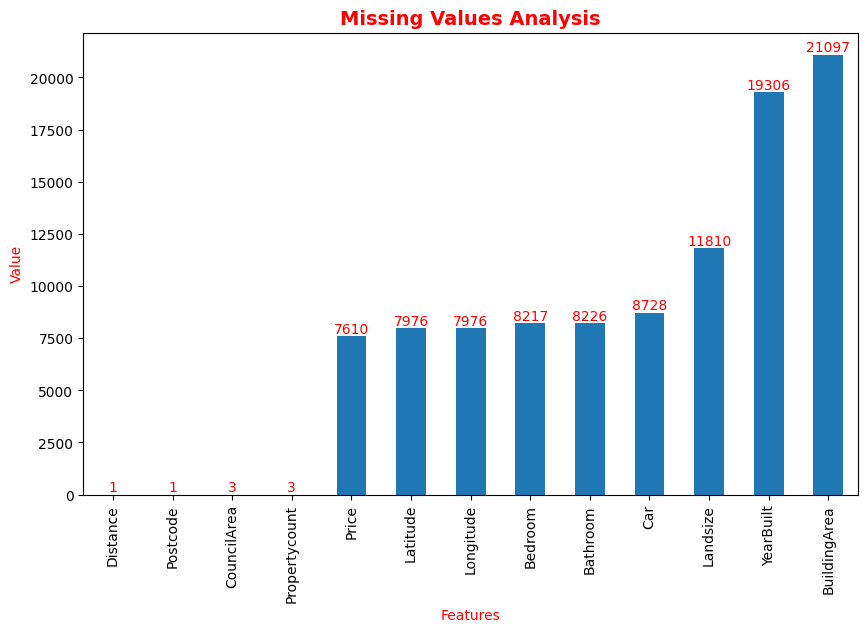

In [20]:
plt.figure(figsize = (10, 6))
missing = df.isnull().sum()
ax = missing[missing>0].sort_values().plot(kind="bar")
for i in ax.containers :
    ax.bar_label(i, color = 'red')
plt.title('Missing Values Analysis', fontsize = 14, fontweight = 'bold', color = 'red')
plt.xlabel('Features',color = 'red')
plt.ylabel('Value',color = 'red')
plt.show()

# Numerical Features Distribution + Categorical Features Analysis

In [21]:
df.Rooms.value_counts()

Rooms
3     15084
2      8332
4      7956
5      1737
1      1479
6       204
7        32
8        19
10        6
9         4
12        3
16        1
Name: count, dtype: int64

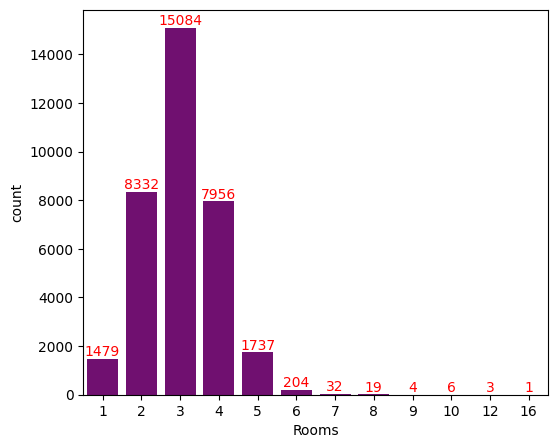

In [22]:
plt.figure(figsize = (6, 5))
ax = sns.countplot(x=df.Rooms, color = 'purple')
for i in ax.containers :
    ax.bar_label(i, color = 'red')
plt.show()

In [23]:
df.Type.value_counts()

Type
h    23980
u     7297
t     3580
Name: count, dtype: int64

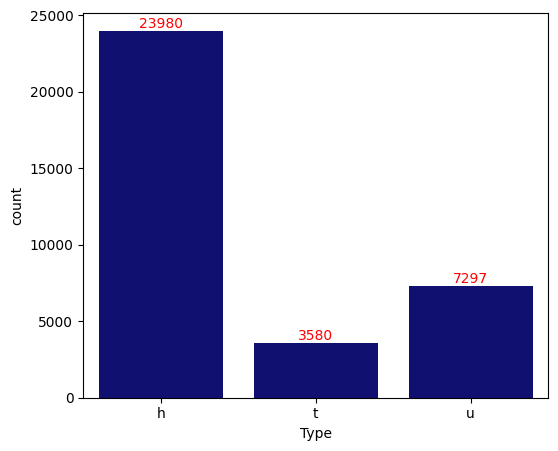

In [24]:
plt.figure(figsize = (6, 5))
ax = sns.countplot(x=df.Type, color = 'navy')
for i in ax.containers :
    ax.bar_label(i, color = 'red')
plt.show()

In [25]:
df.Method.value_counts()

Method
S     19744
SP     5095
PI     4850
VB     3108
SN     1317
PN      308
SA      226
W       173
SS       36
Name: count, dtype: int64

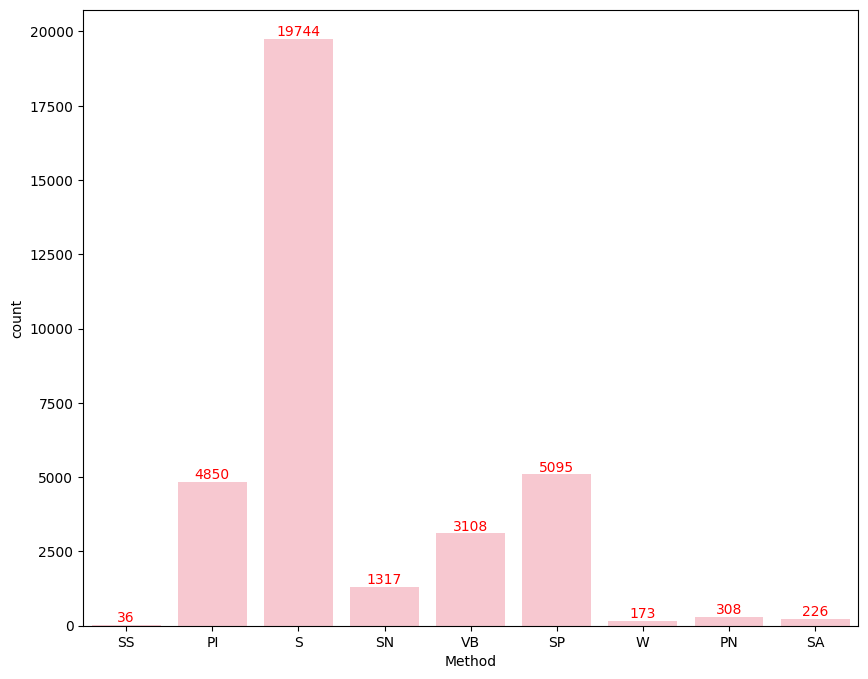

In [26]:
plt.figure(figsize = (10, 8))
ax = sns.countplot(x = df['Method'], color = 'pink')
for i in ax.containers :
    ax.bar_label(i, color = 'red')
plt.show()

In [27]:
df.Bedroom.value_counts()

Bedroom
3.0     11881
4.0      6348
2.0      5777
5.0      1427
1.0       966
6.0       168
7.0        30
0.0        17
8.0        13
9.0         5
10.0        4
20.0        1
30.0        1
12.0        1
16.0        1
Name: count, dtype: int64

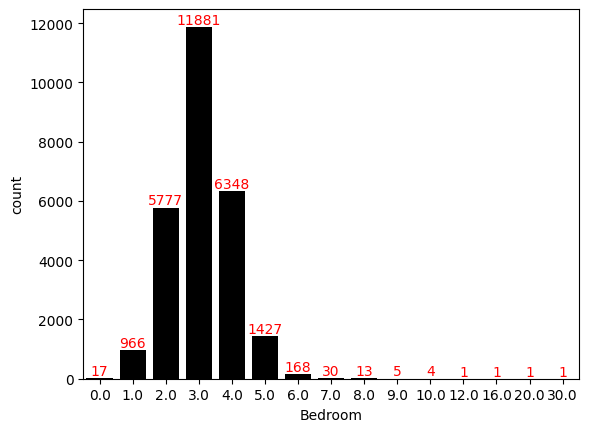

In [28]:
ax = sns.countplot(x=df.Bedroom, color = 'black')
for i in ax.containers :
    ax.bar_label(i, color = 'red')
plt.show()

In [29]:
df.Bathroom.value_counts()

Bathroom
1.0     12969
2.0     11064
3.0      2181
4.0       269
5.0        77
0.0        46
6.0        16
7.0         4
8.0         3
12.0        1
9.0         1
Name: count, dtype: int64

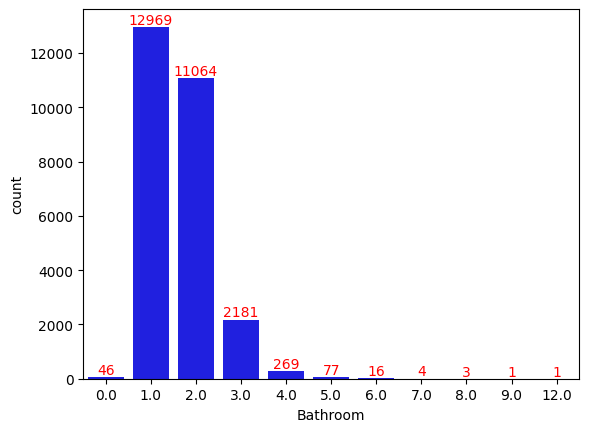

In [30]:
ax = sns.countplot(x=df.Bathroom, color = 'blue')
for i in ax.containers :
    ax.bar_label(i, color = 'red')
plt.show()

In [31]:
df.Distance.value_counts()

Distance
11.2    1420
13.8     681
9.2      665
7.8      662
10.5     660
        ... 
22.9       1
33.0       1
29.5       1
31.4       1
32.6       1
Name: count, Length: 215, dtype: int64

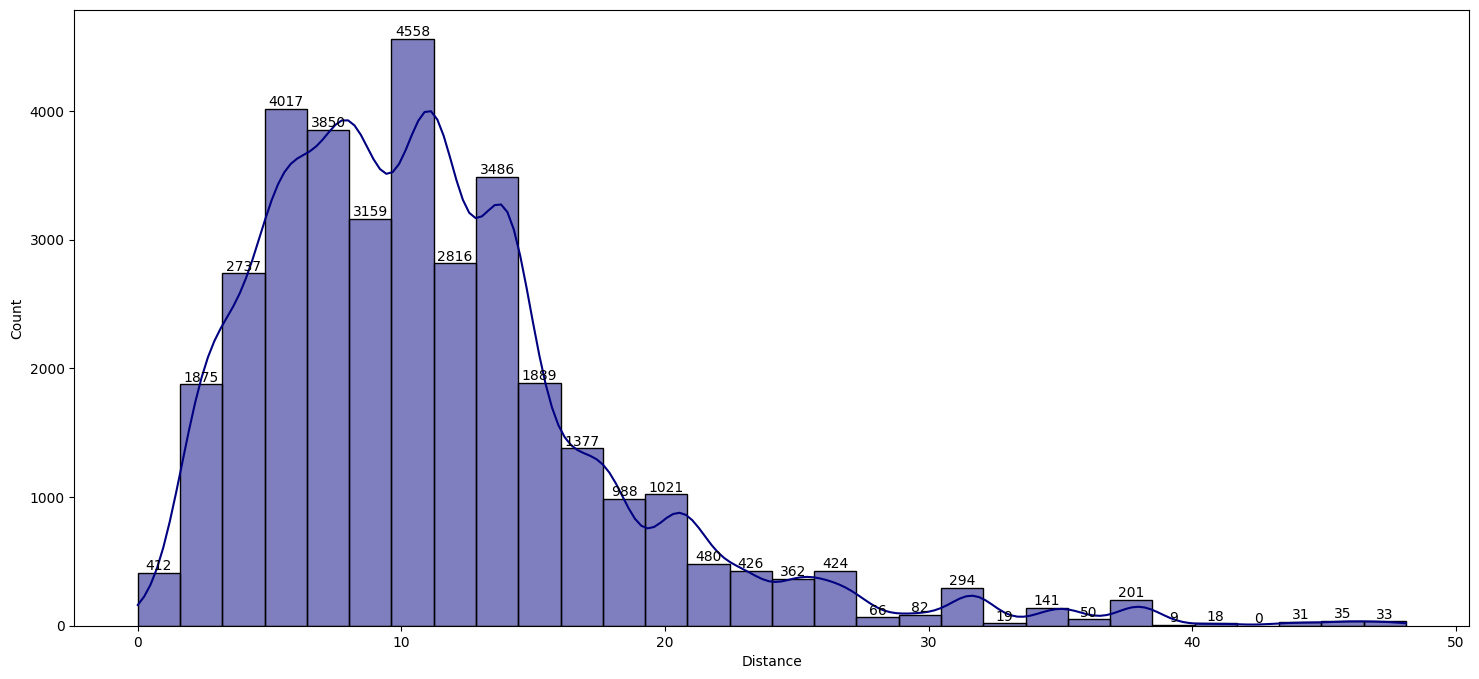

In [32]:
plt.figure(figsize = (18, 8))
ax = sns.histplot(data = df, x=df.Distance, bins = 30, kde = True, color = 'navy')
for i in ax.containers :
    ax.bar_label(i)
plt.show()

In [33]:
df.Propertycount.value_counts()

Propertycount
21650.0    844
8870.0     722
10969.0    583
14949.0    552
10412.0    491
          ... 
794.0        1
83.0         1
335.0        1
604.0        1
1424.0       1
Name: count, Length: 342, dtype: int64

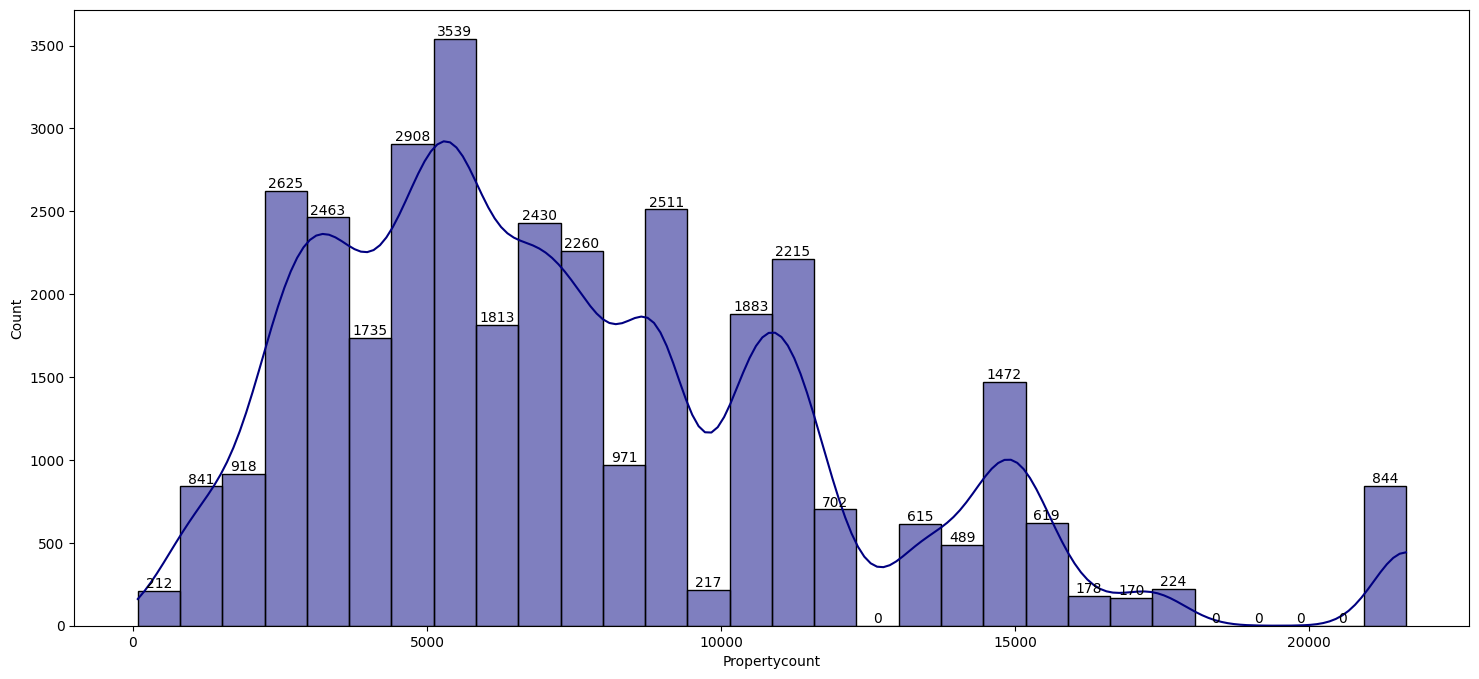

In [34]:
plt.figure(figsize = (18, 8))
ax = sns.histplot(data = df, x=df.Propertycount, bins = 30, kde = True, color = 'navy')
for i in ax.containers :
    ax.bar_label(i)
plt.show()

In [35]:
df.Regionname.value_counts()

Regionname
Southern Metropolitan         11836
Northern Metropolitan          9560
Western Metropolitan           6799
Eastern Metropolitan           4377
South-Eastern Metropolitan     1739
Eastern Victoria                228
Northern Victoria               203
Western Victoria                115
Name: count, dtype: int64

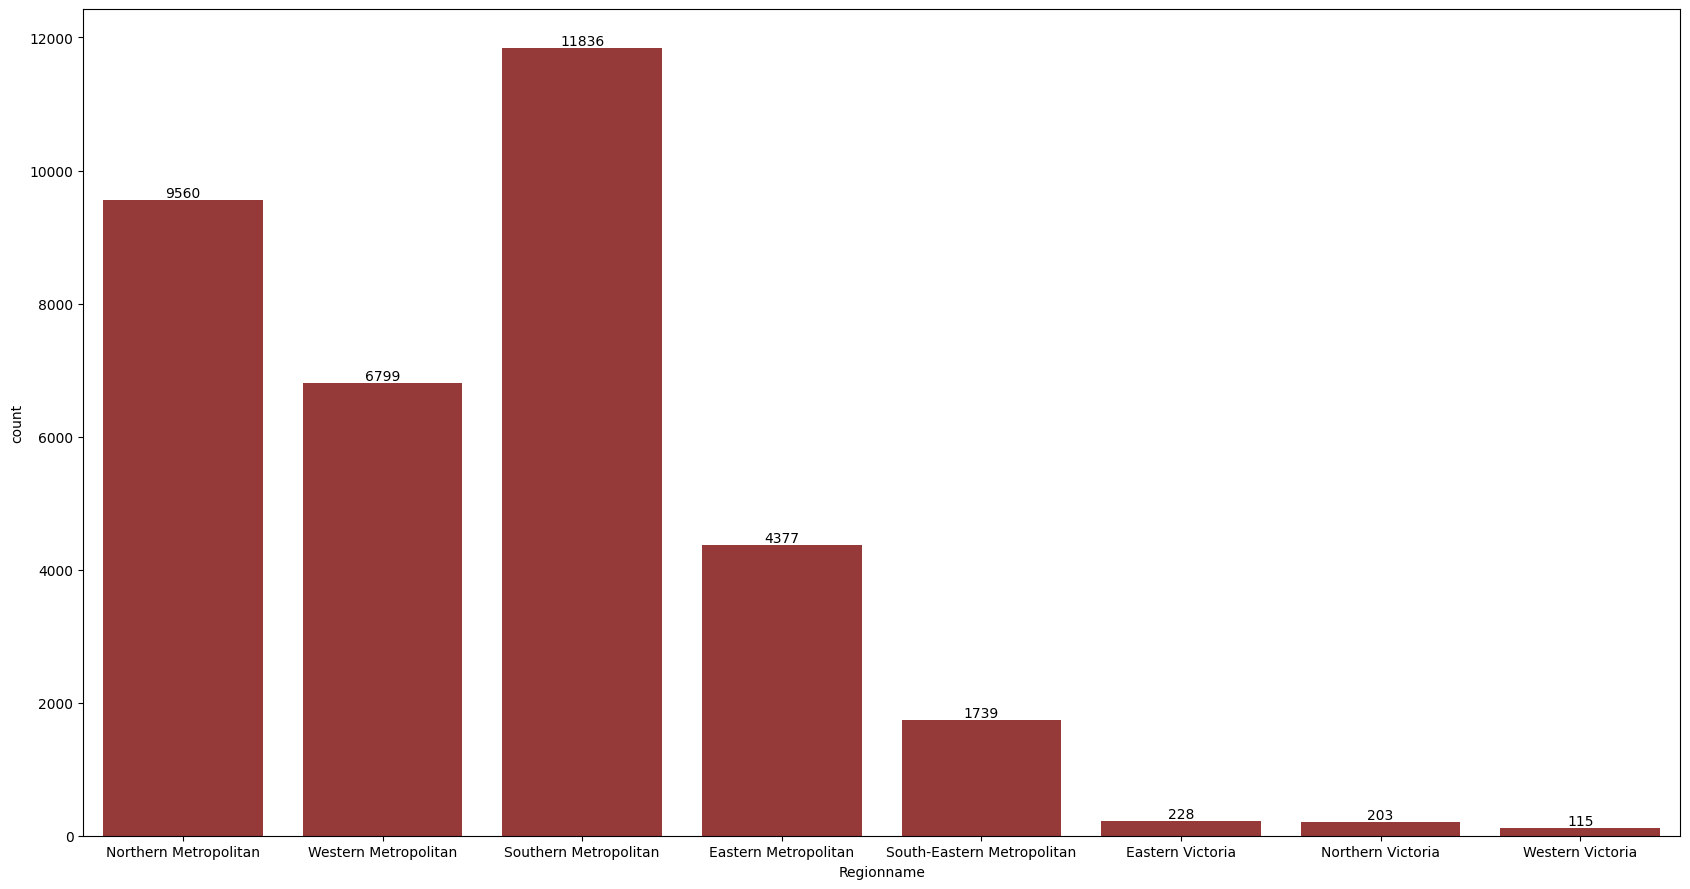

In [36]:
plt.figure(figsize = (17, 9))
ax = sns.countplot(data = df, x=df.Regionname, color = 'brown')
for i in ax.containers :
    ax.bar_label(i)
plt.tight_layout()
plt.show()

In [37]:
df.CouncilArea.value_counts()

CouncilArea
Boroondara City Council           3675
Darebin City Council              2851
Moreland City Council             2122
Glen Eira City Council            2006
Melbourne City Council            1952
Banyule City Council              1861
Moonee Valley City Council        1791
Bayside City Council              1764
Brimbank City Council             1593
Monash City Council               1466
Stonnington City Council          1460
Maribyrnong City Council          1451
Port Phillip City Council         1280
Hume City Council                 1214
Yarra City Council                1186
Manningham City Council           1046
Hobsons Bay City Council           942
Kingston City Council              871
Whittlesea City Council            828
Wyndham City Council               624
Whitehorse City Council            618
Maroondah City Council             506
Knox City Council                  371
Greater Dandenong City Council     314
Melton City Council                292
Frankston Cit

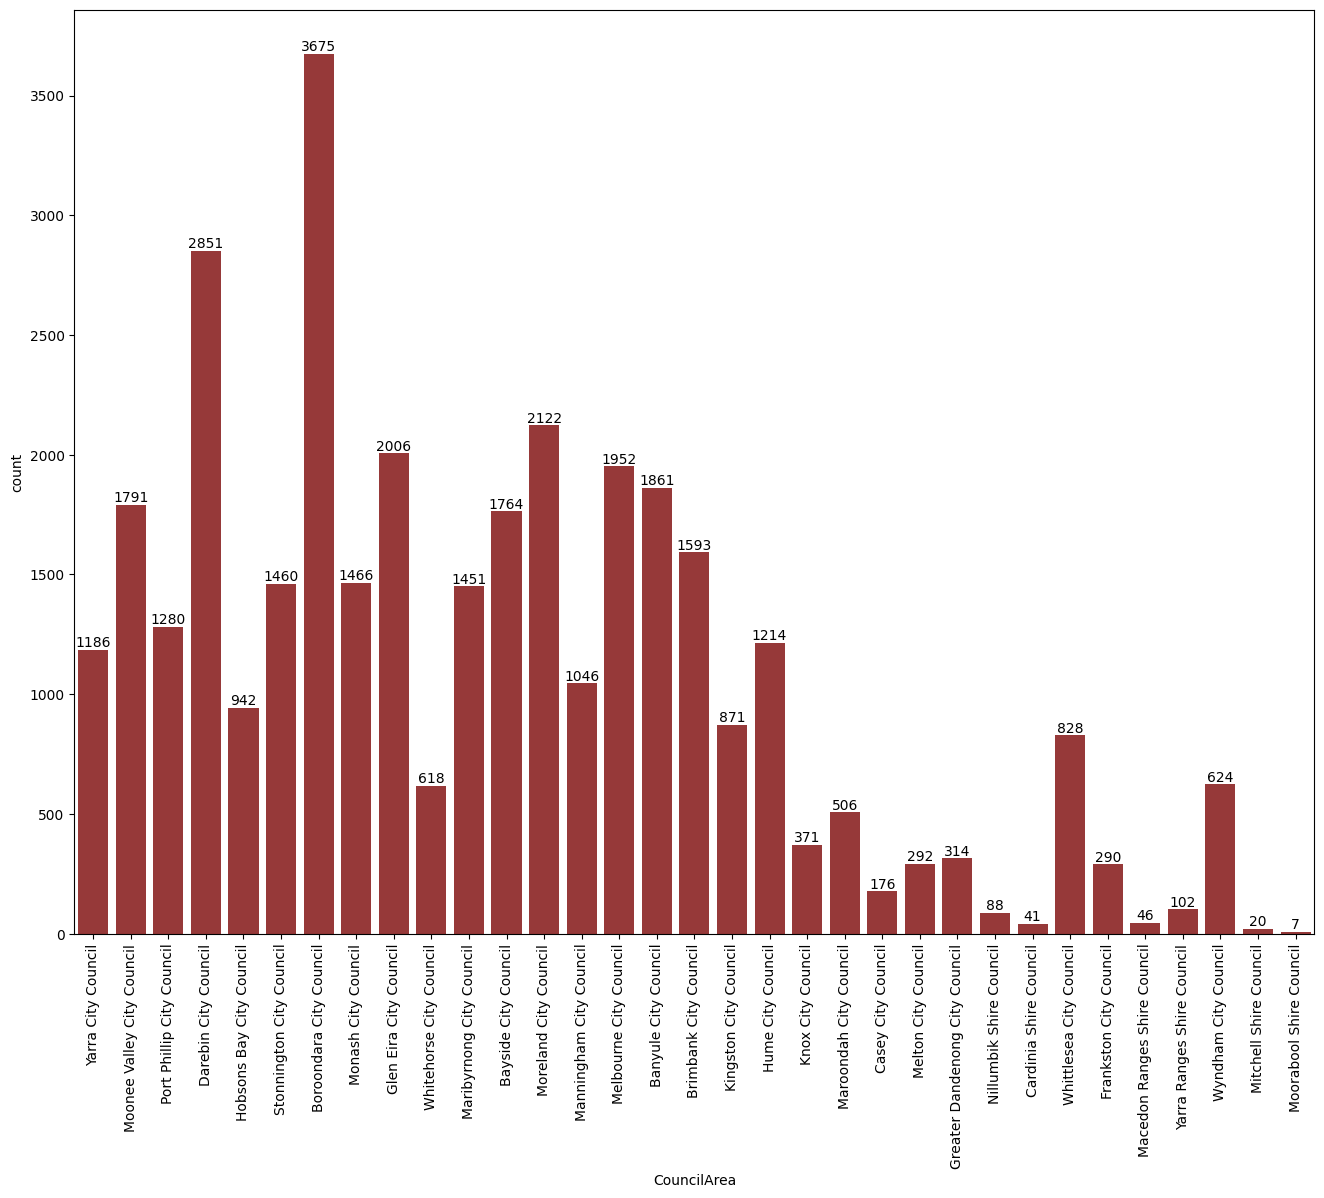

In [38]:
plt.figure(figsize = (16, 12))
ax = sns.countplot(data = df, x=df.CouncilArea, color = 'brown')
for i in ax.containers :
    ax.bar_label(i)
plt.xticks(rotation = 90)
plt.show()

# Target Variable Analysis (Price)

In [39]:
df.Price

0              NaN
1         840000.0
2        1275000.0
3        1455000.0
4              NaN
           ...    
34852     475000.0
34853     591000.0
34854          NaN
34855     780500.0
34856     791000.0
Name: Price, Length: 34857, dtype: float64

In [40]:
df.Price.max()

11200000.0

In [41]:
df.Price.min()

85000.0

In [42]:
df.shape

(34857, 22)

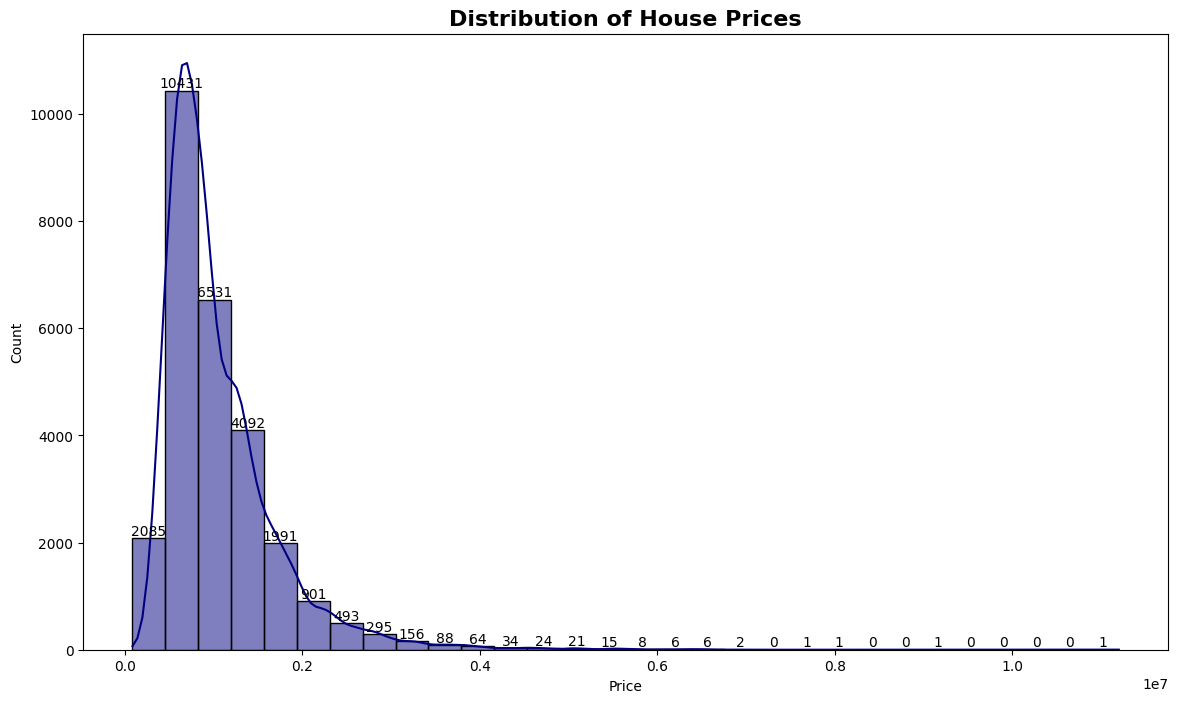

In [43]:
plt.figure(figsize = (14, 8))
ax = sns.histplot(data = df, x=df.Price, bins = 30, kde = True, color = 'navy')
for i in ax.containers :
    ax.bar_label(i)
plt.title("Distribution of House Prices", fontsize = 16, fontweight = 'bold')
plt.show()

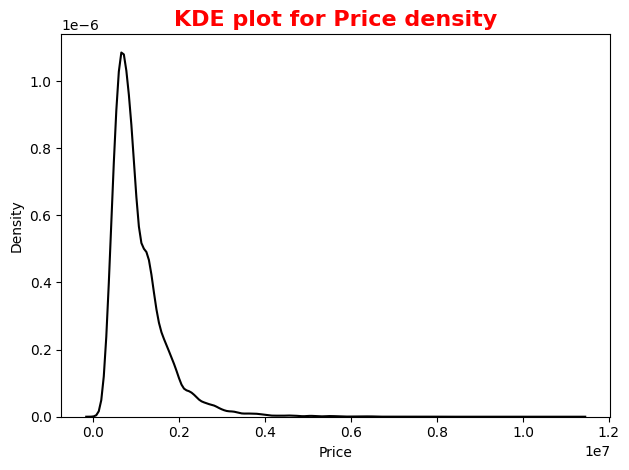

In [44]:
sns.kdeplot(data = df, x = df.Price, color = 'k')
plt.title('KDE plot for Price density', color = 'r', fontweight = 'bold', fontsize = 16)
plt.tight_layout()
plt.show()

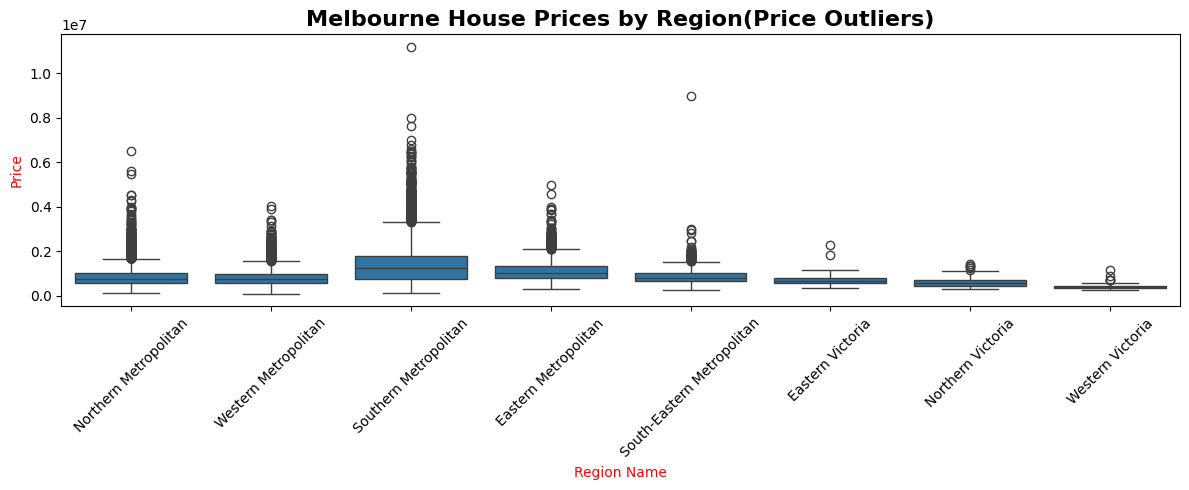

In [45]:
plt.figure(figsize = (12, 5))
sns.boxplot(data = df, x="Regionname", y="Price")
plt.xticks(rotation = 45)
plt.title("Melbourne House Prices by Region(Price Outliers)", fontweight = 'bold', fontsize = 16)
plt.xlabel('Region Name', color = 'r')
plt.ylabel('Price', color = 'r')
plt.tight_layout()
plt.show()

# Correlation Matrix

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         34857 non-null  object 
 1   Address        34857 non-null  object 
 2   Rooms          34857 non-null  int64  
 3   Type           34857 non-null  object 
 4   Method         34857 non-null  object 
 5   SellerG        34857 non-null  object 
 6   Date           34857 non-null  object 
 7   Distance       34856 non-null  float64
 8   Postcode       34856 non-null  float64
 9   Bedroom        26640 non-null  float64
 10  Bathroom       26631 non-null  float64
 11  Car            26129 non-null  float64
 12  Landsize       23047 non-null  float64
 13  BuildingArea   13760 non-null  object 
 14  YearBuilt      15551 non-null  float64
 15  CouncilArea    34854 non-null  object 
 16  Latitude       26881 non-null  float64
 17  Longitude      26881 non-null  float64
 18  Region

In [47]:
col = []
for i in df.columns :
    if df[i].dtype != 'object' :
        col.append(str(i))

In [48]:
dummy1 = df[['Rooms', 'Distance', 'Postcode', 'Bedroom', 'Bathroom', 'Car', 'Landsize', 'YearBuilt', 'Latitude', 'Longitude', 'Propertycount', 'Price']]
dummy1

,Rooms,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,YearBuilt,Latitude,Longitude,Propertycount,Price
0,2,2.5,3067.0,2.0,1.0,1.0,126.0,NaN,-37.80140,144.99580,4019.0,NaN
1,3,13.5,3042.0,3.0,2.0,1.0,303.0,2016.0,-37.71800,144.87800,3464.0,840000.0
2,2,3.3,3206.0,2.0,1.0,0.0,120.0,1900.0,-37.84590,144.95550,3280.0,1275000.0
3,2,3.3,3206.0,2.0,1.0,0.0,159.0,NaN,-37.84500,144.95380,3280.0,1455000.0
4,3,6.4,3078.0,3.0,2.0,1.0,174.0,2003.0,-37.78180,145.01980,2211.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
34852,3,12.0,3073.0,3.0,1.0,1.0,NaN,1990.0,-37.69769,145.02332,21650.0,475000.0
34853,4,20.6,3064.0,4.0,2.0,2.0,NaN,1995.0,-37.63665,144.92976,5833.0,591000.0
34854,4,22.2,3172.0,4.0,2.0,2.0,534.0,1970.0,-37.97037,145.15449,4054.0,NaN
34855,3,22.2,3172.0,3.0,2.0,1.0,544.0,NaN,-37.97751,145.14813,4054.0,780500.0


In [49]:
col

['Rooms',
 'Distance',
 'Postcode',
 'Bedroom',
 'Bathroom',
 'Car',
 'Landsize',
 'YearBuilt',
 'Latitude',
 'Longitude',
 'Propertycount',
 'Price']

In [50]:
dummy = df[col]
dummy

,Rooms,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,YearBuilt,Latitude,Longitude,Propertycount,Price
0,2,2.5,3067.0,2.0,1.0,1.0,126.0,NaN,-37.80140,144.99580,4019.0,NaN
1,3,13.5,3042.0,3.0,2.0,1.0,303.0,2016.0,-37.71800,144.87800,3464.0,840000.0
2,2,3.3,3206.0,2.0,1.0,0.0,120.0,1900.0,-37.84590,144.95550,3280.0,1275000.0
3,2,3.3,3206.0,2.0,1.0,0.0,159.0,NaN,-37.84500,144.95380,3280.0,1455000.0
4,3,6.4,3078.0,3.0,2.0,1.0,174.0,2003.0,-37.78180,145.01980,2211.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
34852,3,12.0,3073.0,3.0,1.0,1.0,NaN,1990.0,-37.69769,145.02332,21650.0,475000.0
34853,4,20.6,3064.0,4.0,2.0,2.0,NaN,1995.0,-37.63665,144.92976,5833.0,591000.0
34854,4,22.2,3172.0,4.0,2.0,2.0,534.0,1970.0,-37.97037,145.15449,4054.0,NaN
34855,3,22.2,3172.0,3.0,2.0,1.0,544.0,NaN,-37.97751,145.14813,4054.0,780500.0


In [51]:
dummy.corr()

,Rooms,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,YearBuilt,Latitude,Longitude,Propertycount,Price
Rooms,1.000000,0.271511,0.085890,0.946755,0.611826,0.393878,0.037402,-0.012749,0.004872,0.103235,-0.071677,0.465238
Distance,0.271511,1.000000,0.481566,0.269524,0.126201,0.241835,0.060862,0.323059,-0.100417,0.200946,-0.018140,-0.211384
Postcode,0.085890,0.481566,1.000000,0.089292,0.120080,0.067886,0.040664,0.089805,-0.231027,0.362895,0.017108,0.044950
Bedroom,0.946755,0.269524,0.089292,1.000000,0.614892,0.388491,0.037019,-0.002022,0.003447,0.106164,-0.053451,0.430275
Bathroom,0.611826,0.126201,0.120080,0.614892,1.000000,0.307518,0.036333,0.167955,-0.059183,0.106531,-0.032887,0.429878
Car,0.393878,0.241835,0.067886,0.388491,0.307518,1.000000,0.037829,0.128702,-0.009020,0.047213,-0.009617,0.201803
Landsize,0.037402,0.060862,0.040664,0.037019,0.036333,0.037829,1.000000,0.044474,0.025318,-0.002582,-0.018195,0.032748
YearBuilt,-0.012749,0.323059,0.089805,-0.002022,0.167955,0.128702,0.044474,1.000000,0.091592,-0.022175,0.022420,-0.333306
Latitude,0.004872,-0.100417,-0.231027,0.003447,-0.059183,-0.009020,0.025318,0.091592,1.000000,-0.345589,0.011112,-0.215607
Longitude,0.103235,0.200946,0.362895,0.106164,0.106531,0.047213,-0.002582,-0.022175,-0.345589,1.000000,0.016326,0.197874


Text(0.5, 1.0, 'Correlation between Numeric features with Price columns')

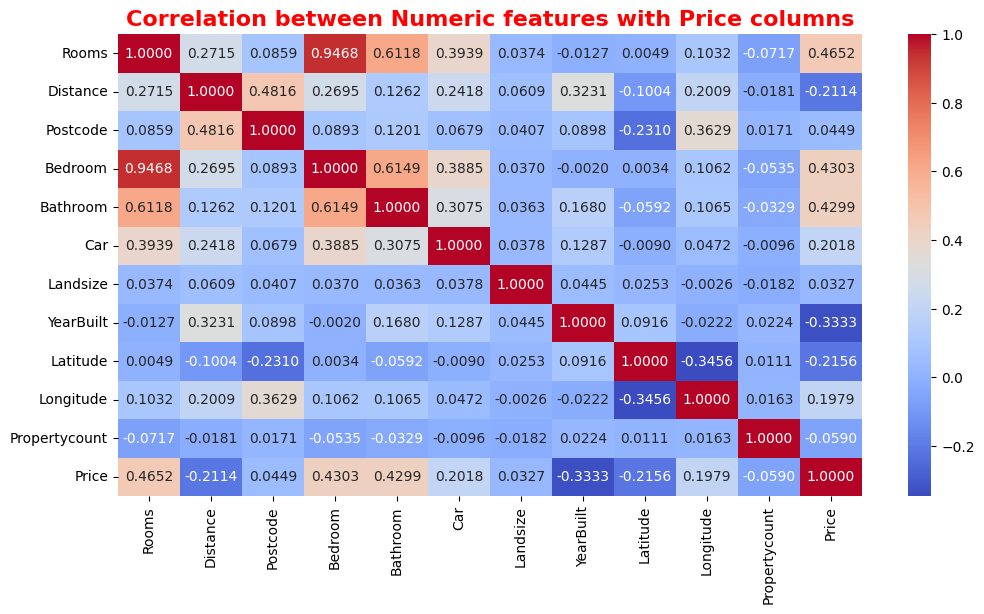

In [52]:
plt.figure(figsize = (12, 6))
sns.heatmap(dummy.corr(), annot = True, fmt = ".4f", cmap="coolwarm")
plt.title('Correlation between Numeric features with Price columns', color = 'red', fontsize = 16, fontweight = 'bold')

# Price Relationship Analysis

## Rooms vs Price

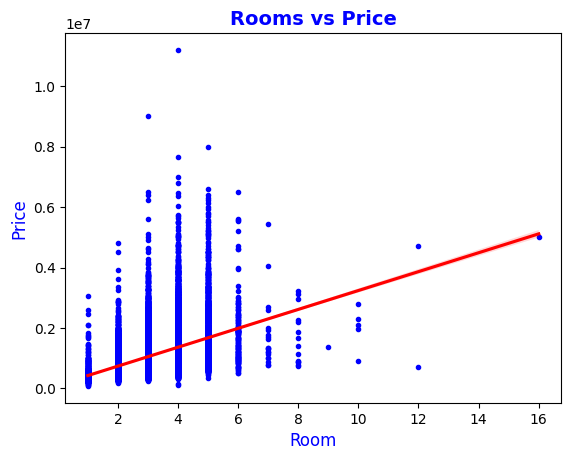

In [53]:
plt.scatter(df['Rooms'], df['Price'], color = 'b',  marker = '.')
sns.regplot(data=df, x="Rooms", y="Price", scatter=False, color="red")
plt.title('Rooms vs Price', color = 'b', fontsize = 14, fontweight = 'bold')
plt.xlabel('Room', color = 'b', fontsize = 12)
plt.ylabel('Price', color = 'b', fontsize = 12)
plt.show()

## Bathroom vs Price

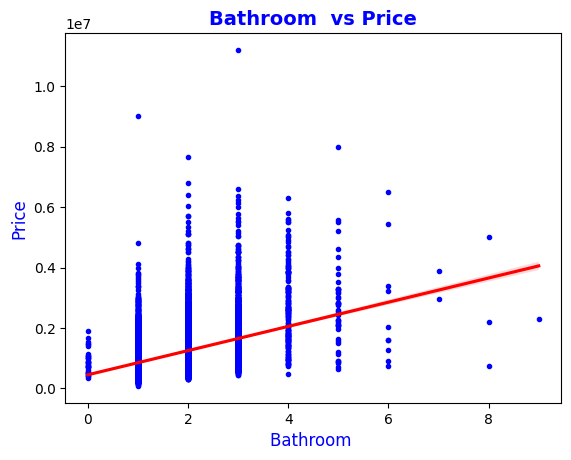

In [54]:
plt.scatter(df['Bathroom'], df['Price'], color = 'b',  marker = '.')
sns.regplot(data=df, x="Bathroom", y="Price", scatter=False, color="red")
plt.title('Bathroom  vs Price', color = 'b', fontsize = 14, fontweight = 'bold')
plt.xlabel('Bathroom ', color = 'b', fontsize = 12)
plt.ylabel('Price', color = 'b', fontsize = 12)
plt.show()

## Bedroom vs Price

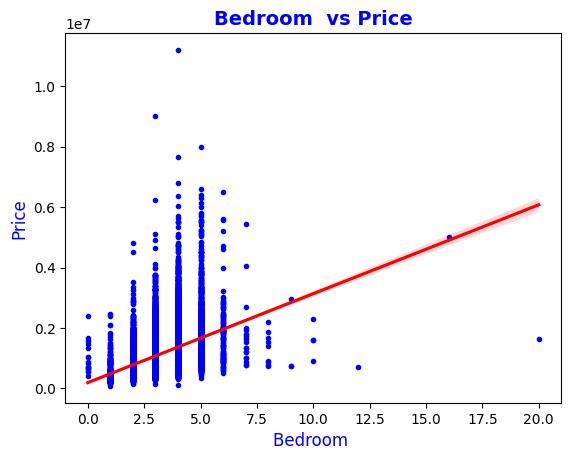

In [55]:
plt.scatter(df['Bedroom'], df['Price'], color = 'b',  marker = '.')
sns.regplot(data=df, x="Bedroom", y="Price", scatter=False, color="red")
plt.title('Bedroom  vs Price', color = 'b', fontsize = 14, fontweight = 'bold')
plt.xlabel('Bedroom ', color = 'b', fontsize = 12)
plt.ylabel('Price', color = 'b', fontsize = 12)
plt.show()

## BuildingArea vs Price

In [56]:
df1['BuildingArea'] = pd.to_numeric(df1['BuildingArea'], errors='coerce')

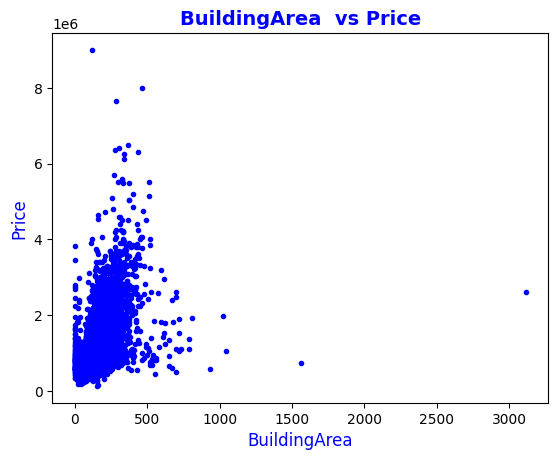

In [57]:
plt.scatter(df1['BuildingArea'], df1['Price'], color = 'b',  marker = '.')
plt.title('BuildingArea  vs Price', color = 'b', fontsize = 14, fontweight = 'bold')
plt.xlabel('BuildingArea', color = 'b', fontsize = 12)
plt.ylabel('Price', color = 'b', fontsize = 12)
plt.show()

## Landsize vs Price

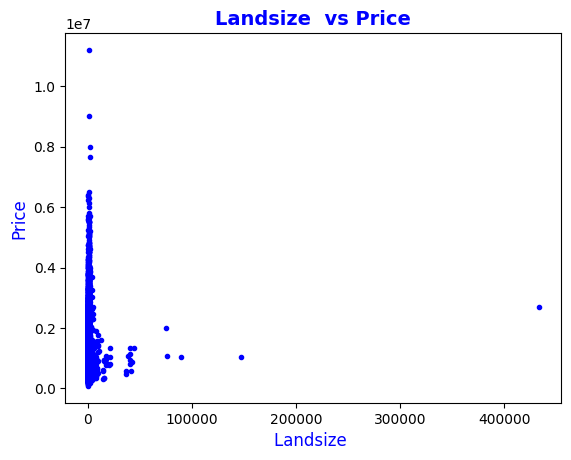

In [58]:
plt.scatter(df['Landsize'], df['Price'], color = 'b',  marker = '.')
plt.title('Landsize  vs Price', color = 'b', fontsize = 14, fontweight = 'bold')
plt.xlabel('Landsize ', color = 'b', fontsize = 12)
plt.ylabel('Price', color = 'b', fontsize = 12)
plt.show()

## Distance vs Price

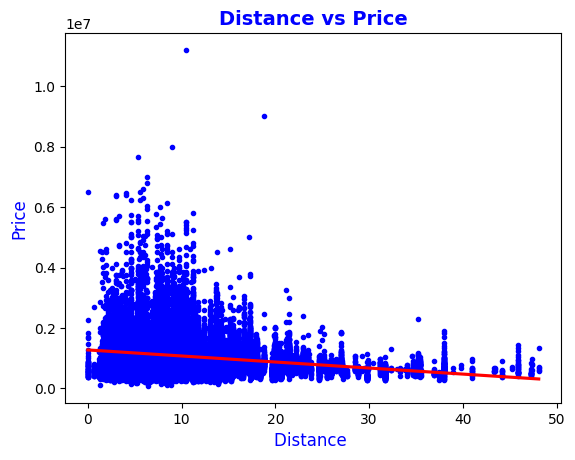

In [59]:
plt.scatter(df['Distance'], df['Price'], color = 'b',  marker = '.')
sns.regplot(data=df, x="Distance", y="Price", scatter=False, color="red")
plt.title('Distance vs Price', color = 'b', fontsize = 14, fontweight = 'bold')
plt.xlabel('Distance ', color = 'b', fontsize = 12)
plt.ylabel('Price', color = 'b', fontsize = 12)
plt.show()

# Box Plot

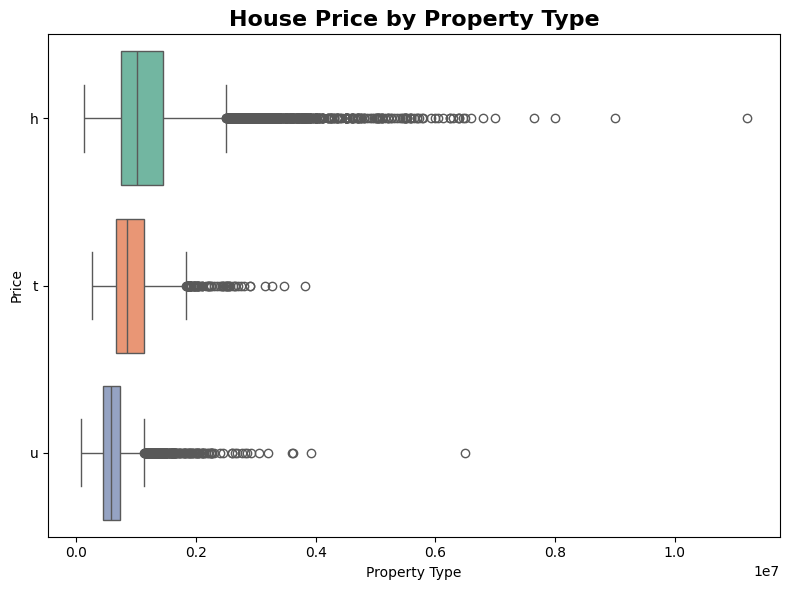

In [60]:
plt.figure(figsize=(8, 6))
sns.boxplot(df, x='Price', y='Type', palette="Set2")

plt.title("House Price by Property Type", fontsize=16, fontweight="bold")
plt.xlabel("Property Type")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

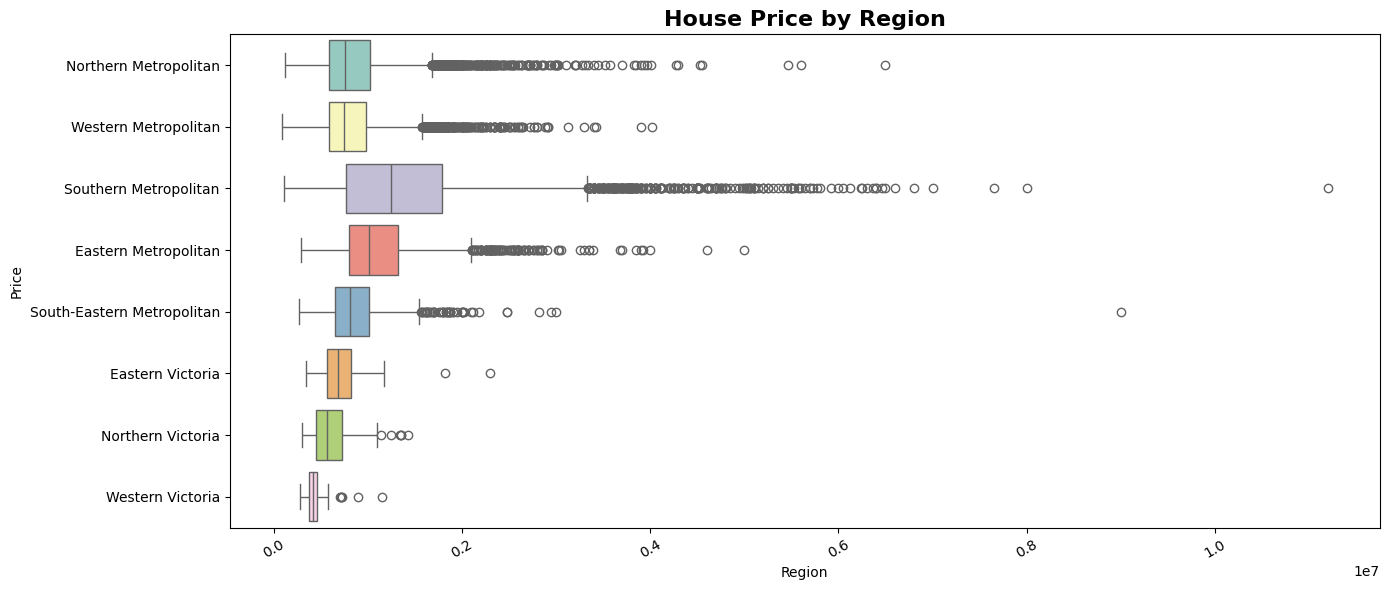

In [61]:
plt.figure(figsize=(14, 6))
sns.boxplot(df, x="Price", y="Regionname", palette="Set3")

plt.title("House Price by Region", fontsize=16, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Price")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

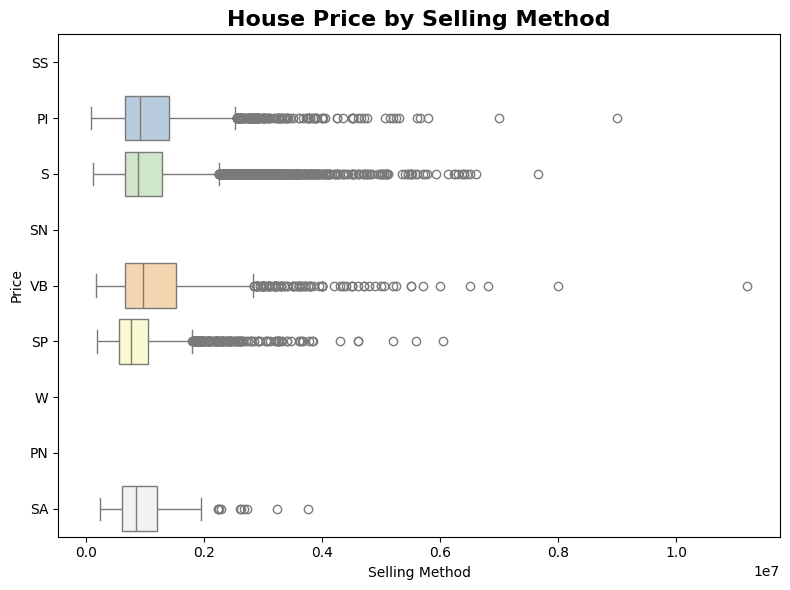

In [62]:
plt.figure(figsize=(8, 6))
sns.boxplot(df, x='Price', y='Method', palette="Pastel1")

plt.title("House Price by Selling Method", fontsize=16, fontweight="bold")
plt.xlabel("Selling Method")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

## Price vs Regionname (Without Outliers)

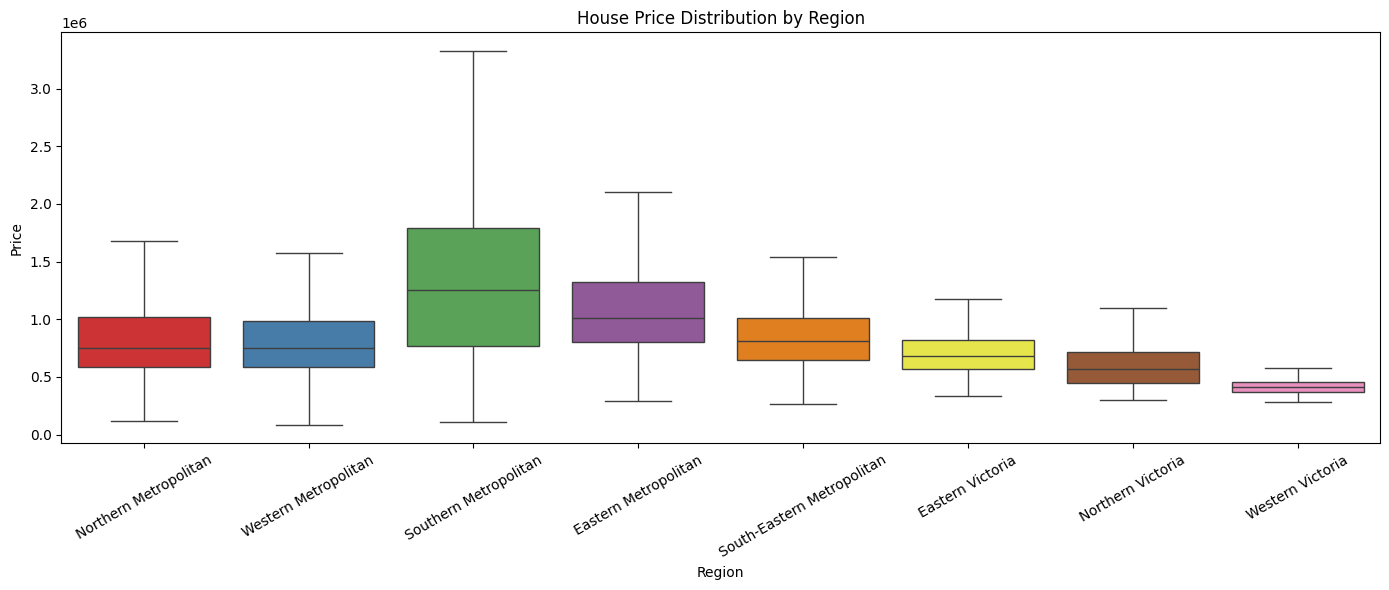

In [63]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df,
    x="Regionname",
    y="Price",
    showfliers=False,
    palette="Set1"
)

plt.title("House Price Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Price")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Pair Plot

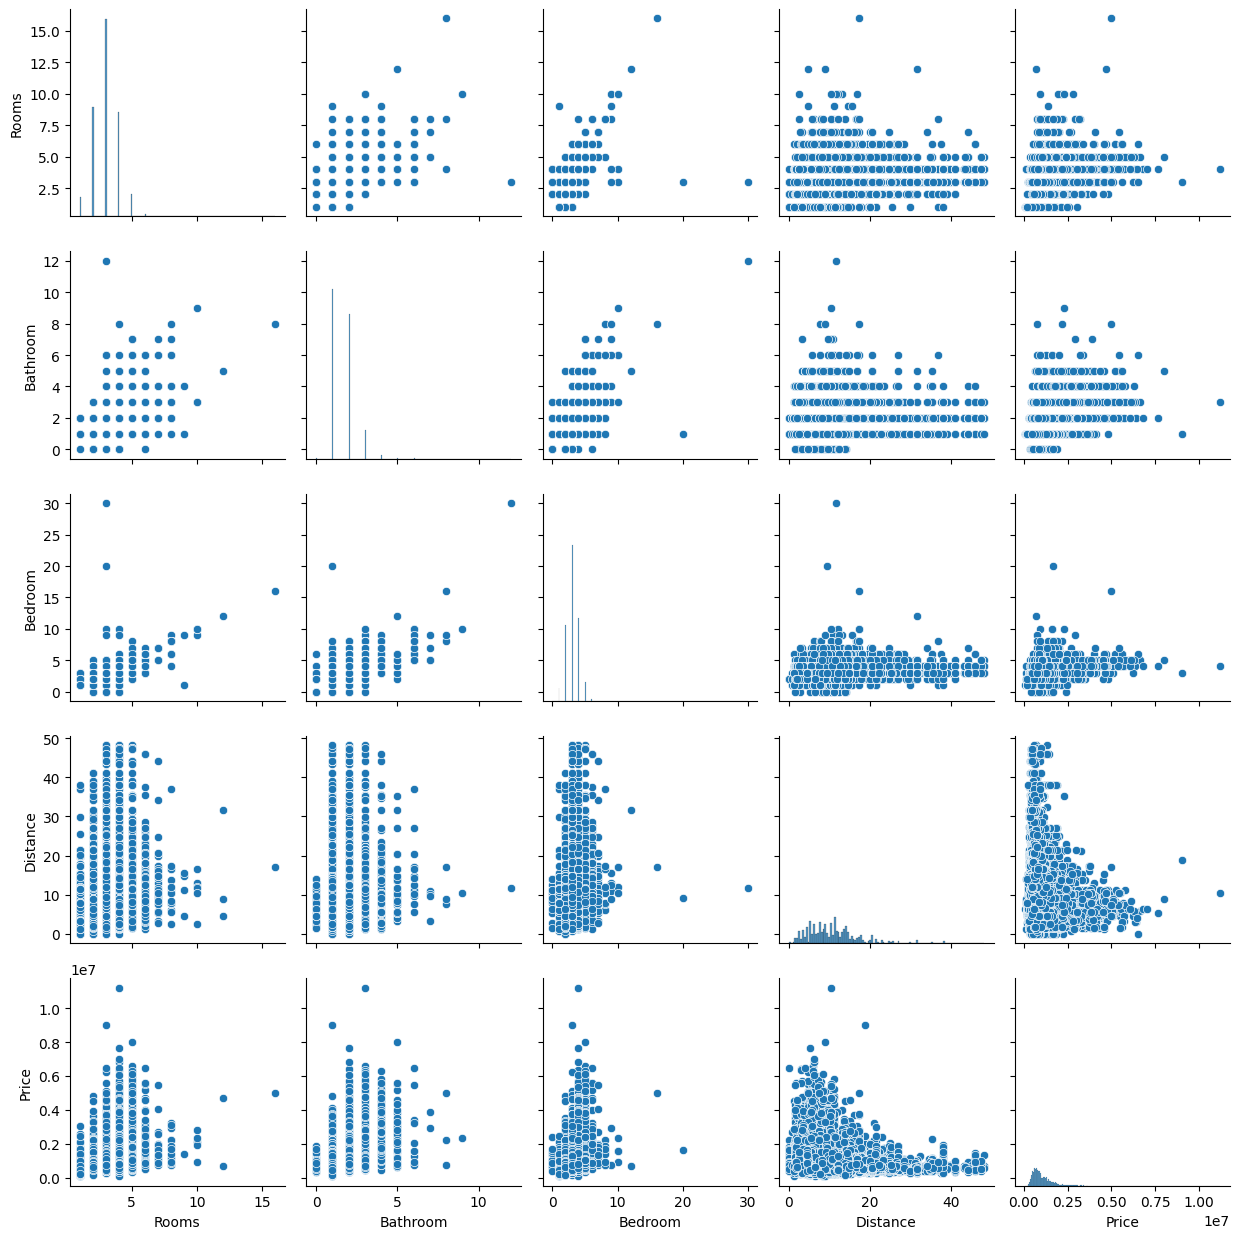

In [64]:
sns.pairplot(data = df[['Rooms', 'Bathroom', 'Bedroom', 'BuildingArea', 'Distance', 'Price']], dropna=True)
plt.tight_layout()

# Geographic Analysis

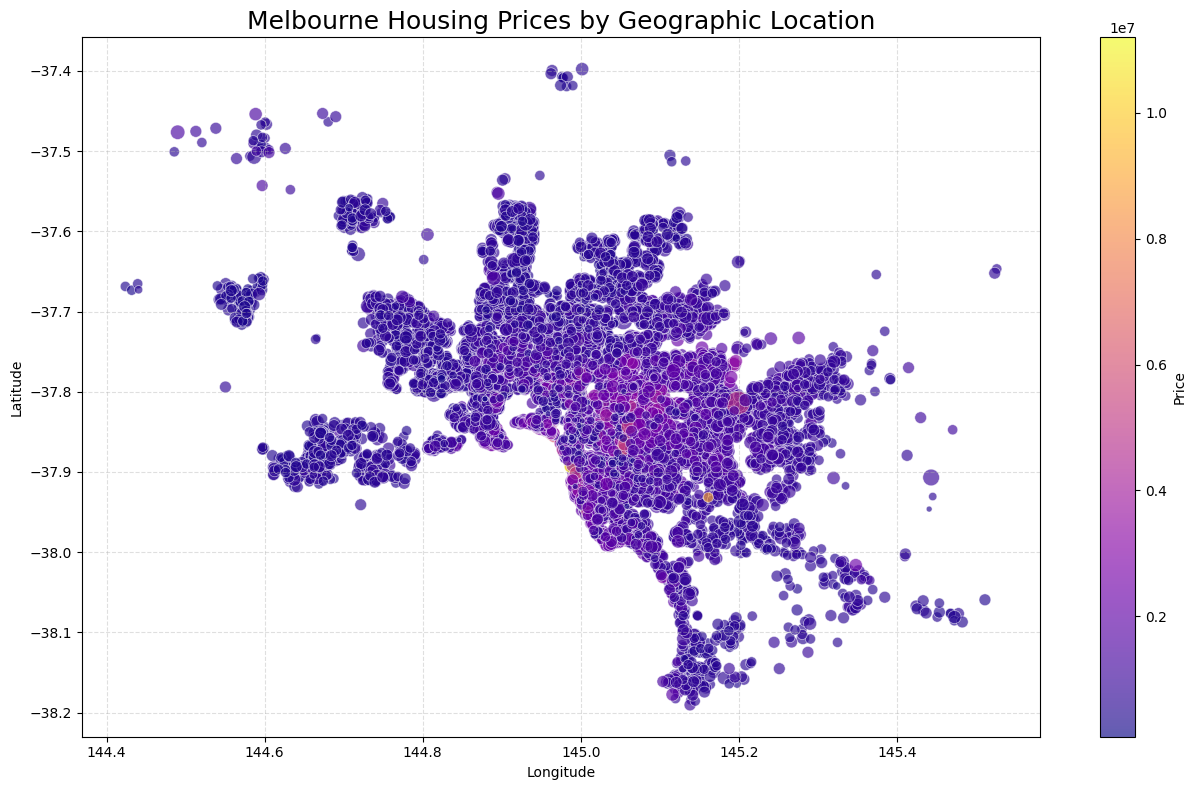

In [65]:
plt.figure(figsize=(13, 8))
scatter = plt.scatter( 
    x = df["Longitude"],
    y=df["Latitude"],
    c=df["Price"],
    s=df["Rooms"] * 18,
    cmap="plasma",
    alpha=0.65,
    edgecolors="white",
    linewidth=0.5
)

plt.colorbar(scatter, label="Price")
plt.title("Melbourne Housing Prices by Geographic Location", fontsize=18)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Top 10 Expensive Suburbs (Average Price)

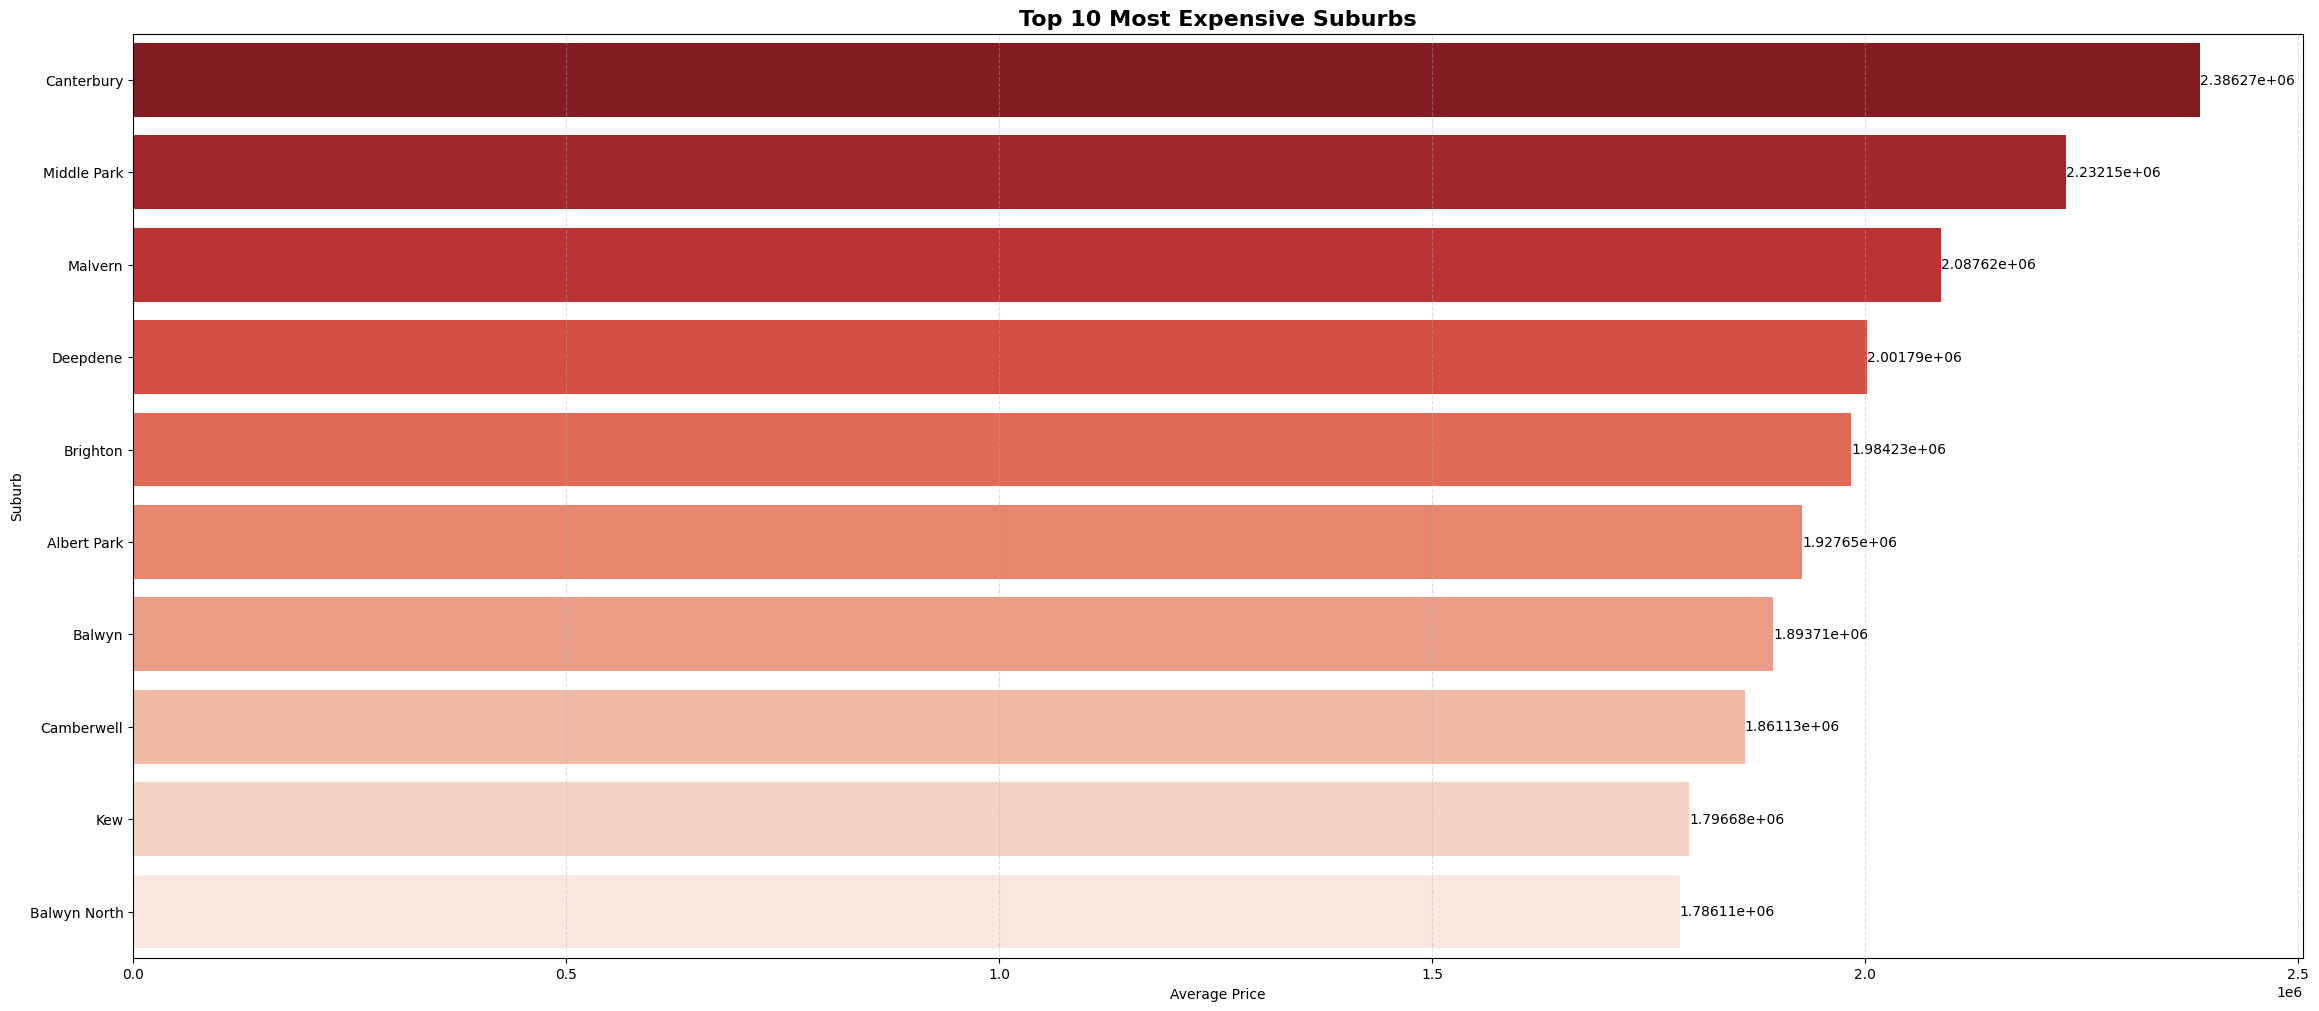

In [66]:
top_suburbs = (
    df.groupby("Suburb")["Price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# Plot
plt.figure(figsize=(28, 12))

ax = sns.barplot(
    x=top_suburbs.values,
    y=top_suburbs.index,
    palette="Reds_r"
)

for i in ax.containers :
    ax.bar_label(i)

plt.title("Top 10 Most Expensive Suburbs", fontsize=16, fontweight="bold")
plt.xlabel("Average Price")
plt.ylabel("Suburb")
plt.grid(axis="x", linestyle="--", alpha=0.4)
# plt.tight_layout()
plt.show()

# Top 10 Cheapest Suburbs (Average Price)

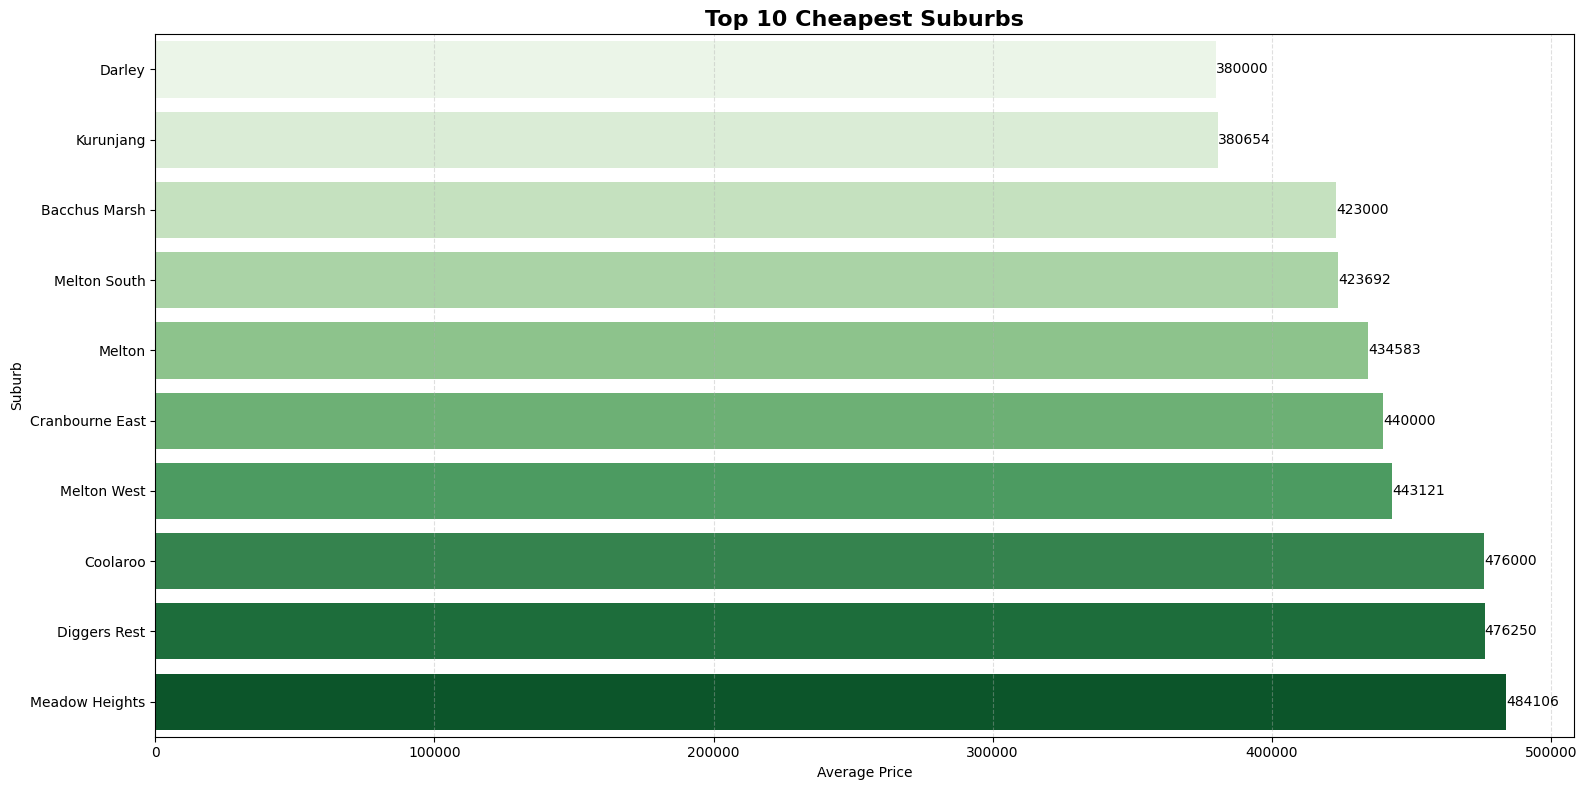

In [67]:
cheapest_suburbs = (
    df.groupby("Suburb")["Price"]
    .mean()
    .sort_values(ascending=True)
    .head(10)
)

# Plot
plt.figure(figsize=(16, 8))

ax = sns.barplot(
    x=cheapest_suburbs.values,
    y=cheapest_suburbs.index,
    palette="Greens"
)

for i in ax.containers :
    ax.bar_label(i)

plt.title("Top 10 Cheapest Suburbs", fontsize=16, fontweight="bold")
plt.xlabel("Average Price")
plt.ylabel("Suburb")

plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.show()

# Skewness Check

In [68]:
df["Price"].skew()

2.5889693410528594

# Top Correlated Features with Price

In [69]:
dummy.corr()["Price"].sort_values()

YearBuilt       -0.333306
Latitude        -0.215607
Distance        -0.211384
Propertycount   -0.059017
Landsize         0.032748
Postcode         0.044950
Longitude        0.197874
Car              0.201803
Bathroom         0.429878
Bedroom          0.430275
Rooms            0.465238
Price            1.000000
Name: Price, dtype: float64

# Major Observations From the EDA

## Missing Values Analysis

### Observation

#### Missing values are concentrated in a few specific columns rather than being evenly distributed across the dataset.

#### BuildingArea, YearBuilt, CouncilArea, Car, Bedroom, and Bathroom contain notable missing values.

#### These missing values must be handled before model training to avoid biased predictions and errors.

---

## Rooms Distribution

### Observation

#### Most properties contain between 2 and 4 rooms.

#### Properties with very large numbers of rooms are relatively rare.

#### The dataset mainly represents medium-sized residential properties.

---

## Property Type Distribution

### Observation

#### Houses are the most common property type in the dataset.

#### Townhouses and units appear less frequently.

#### The dataset is dominated by traditional residential houses.

---

## Selling Method Distribution

### Observation

#### Certain selling methods occur much more frequently than others.

#### The distribution is imbalanced, indicating that some selling methods are preferred in the housing market.

---

## Bedroom Distribution

### Observation

#### Most properties contain between 2 and 4 bedrooms.

#### Extremely large properties with many bedrooms are uncommon.

#### Bedroom counts are consistent with the room distribution observed earlier.

---

## Bathroom Distribution

### Observation

#### Most properties have 1 to 3 bathrooms.

#### Properties with a large number of bathrooms are relatively rare.

#### Bathroom count may contribute positively to property value.

---

## Distance Distribution

### Observation

#### Most properties are located relatively close to the city center.

#### Property frequency decreases as distance increases.

#### The distribution is right-skewed, indicating fewer properties at greater distances.

---

## Property Count Distribution

### Observation

#### Property counts vary significantly across locations.

#### Some areas contain substantially more properties than others.

#### This suggests differences in population density and housing availability.

---

## Region Distribution

### Observation

#### Housing activity is not evenly distributed across all regions.

#### Some regions contribute a much larger number of property records than others.

#### Regional imbalance may influence model learning.

---

## Council Area Distribution

### Observation

#### Certain council areas contain substantially more housing records than others.

#### Housing development and property availability vary considerably between council areas.

---

## Target Variable (Price)

### Observation

#### House prices are strongly right-skewed.

#### Most properties fall within lower-to-middle price ranges.

#### A relatively small number of luxury properties create a long right tail in the distribution.

### Meaning

#### The dataset contains expensive outlier properties.

#### Price transformation (such as log transformation) may improve model performance.

---

## Price Density (KDE Plot)

### Observation

#### House prices are concentrated within a specific price range.

#### Density gradually decreases as prices increase.

#### High-priced properties become increasingly rare.

---

## Price by Region

### Observation

#### Median house prices vary significantly between regions.

#### Some regions consistently contain higher-priced properties.

#### Location appears to be one of the strongest drivers of house prices.

---

## Correlation Matrix

### Strong Positive Relationships

#### Rooms ↗ Price

#### Bedroom ↗ Price

#### Bathroom ↗ Price

#### Car ↗ Price

#### Landsize ↗ Price

#### BuildingArea ↗ Price

### Negative Relationships

#### Distance ↘ Price

### Observation

#### Building area, number of rooms, bedrooms, bathrooms, car spaces, and land size show positive relationships with house prices.

#### Properties located farther from the CBD generally have lower prices.

#### Features associated with property size tend to increase property value.

---

## Rooms vs Price

### Observation

#### Properties with more rooms generally command higher prices.

#### A positive relationship exists between room count and property value.

#### Larger homes tend to be more expensive.

---

## Bathroom vs Price

### Observation

#### House prices increase as the number of bathrooms increases.

#### Bathroom count appears to be a valuable predictor of property price.

#### Properties with multiple bathrooms often belong to higher-value segments.

---

## Bedroom vs Price

### Observation

#### Bedroom count shows a positive relationship with house prices.

#### Properties with more bedrooms generally sell for higher prices.

#### The relationship is positive but slightly weaker than bathroom count.

---

## Building Area vs Price

### Observation

#### Larger building areas are generally associated with higher prices.

#### Building size appears to be one of the strongest indicators of property value.

#### Several extreme outliers are visible among larger properties.

---

## Land Size vs Price

### Observation

#### Properties with larger land sizes generally have higher prices.

#### The relationship is positive but affected by outliers.

#### Land size contributes to property value but may not be the sole determining factor.

---

## Distance vs Price

### Observation

#### House prices generally decrease as distance from the CBD increases.

#### Properties closer to central locations tend to be more expensive.

#### Distance is an important location-based feature.

---

## Price vs Property Type

### Observation

#### Houses generally have higher median prices than units and townhouses.

#### Units tend to occupy the lower end of the price distribution.

#### Property type influences market value.

---

## Price vs Regionname

### Observation

#### Price distributions differ substantially between regions.

#### Some regions contain both higher medians and more expensive outliers.

#### Regional location is a major determinant of property price.

---

## Price vs Method

### Observation

#### Price distributions overlap considerably across selling methods.

#### Selling method alone does not appear to strongly influence property price.

#### Method is likely a weaker predictor compared to structural and location features.

---

## Pair Plot Analysis

### Observation

#### Positive relationships are visible among Rooms, Bedrooms, Bathrooms, BuildingArea, and Price.

#### Price generally increases as property size-related features increase.

#### Several variables exhibit linear trends suitable for Linear Regression.

---

## Geographic Analysis

### Observation

#### Property prices are geographically clustered rather than uniformly distributed.

#### Higher-priced properties appear concentrated in specific locations.

#### Latitude and Longitude contain valuable spatial information for price prediction.

#### Location is one of the most influential factors affecting housing prices.

---

## Top 10 Most Expensive Suburbs

### Observation

#### A small number of suburbs dominate the highest average property prices.

#### These suburbs likely represent premium residential areas.

#### Location significantly influences housing market value.

---

## Top 10 Cheapest Suburbs

### Observation

#### Several suburbs consistently offer lower average property prices.

#### These locations may be farther from key urban centers or contain smaller properties.

#### Housing affordability varies considerably across suburbs.

---

## Skewness Check

### Observation

#### The Price variable exhibits positive skewness.

#### Extreme high-priced properties pull the distribution toward the right.

#### Applying log transformation may help satisfy Linear Regression assumptions.

---

## Top Correlated Features with Price

### Observation

#### BuildingArea, Rooms, Bedrooms, Bathrooms, Landsize, and Car are among the strongest positively correlated features with Price.

#### Distance shows a negative relationship with Price.

#### These variables should be prioritized during model development.


In [70]:
print("The End.")

The End.
